# Sequential Workflow using LangGraph

In [15]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

## Without LLM

In [16]:
# define state
class BMIState(TypedDict):
    height: float  # in meters
    weight: float  # in kilograms
    bmi: float     # Body Mass Index
    category: str  # BMI Category

In [17]:
def calculate_bmi(state: BMIState) -> BMIState:
    """
    Calculate BMI from height and weight.

    BMI = weight (kg) / (height (m))^2

    Args:
        state (BMIState): Input state with height and weight.

    Returns:
        BMIState: Updated state with calculated BMI.
    """
    height = state['height']
    weight = state['weight']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state

def label_bmi(state: BMIState) -> BMIState:
    """
    Label BMI into categories.

    Categories:
        - Underweight: BMI < 18.5
        - Normal weight: 18.5 <= BMI < 24.9
        - Overweight: 25 <= BMI < 29.9
        - Obesity: BMI >= 30

    Args:
        state (BMIState): Input state with calculated BMI.

    Returns:
        BMIState: Updated state with BMI category.
    """
    bmi = state['bmi']
    if bmi < 18.5:
        category = "Underweight"
    elif 18.5 <= bmi < 24.9:
        category = "Normal weight"
    elif 25 <= bmi < 29.9:
        category = "Overweight"
    else:
        category = "Obesity"
    state['category'] = category
    return state

In [18]:
# define the graph
graph = StateGraph(state_schema = BMIState)

# add nodes to the graph
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("label_bmi", label_bmi)

# add edges to the graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "label_bmi")
graph.add_edge("label_bmi", END)

# compile the graph
workflow = graph.compile()

In [19]:
# execute the workflow
initial_state = {"weight": 70, "height": 1.75}
final_state = workflow.invoke(initial_state)
print(final_state)

{'height': 1.75, 'weight': 70, 'bmi': 22.86, 'category': 'Normal weight'}


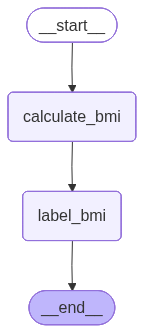

In [20]:
# visualize the graph
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

## With LLM

In [ ]:
!pip install langchain-groq

In [ ]:
from langchain_groq import ChatGroq

In [ ]:
llm = ChatGroq(
    api_key = "xxx",
    model = "llama-3.1-8b-instant",
)

In [30]:
# create the state graph with the LLM model
class LLMState(TypedDict):
    question: str
    answer: str

In [31]:
def llm_qa(state: LLMState) -> LLMState:
    """
    Use LLM to answer a question.

    Args:
        state (LLMState): Input state with question.

    Returns:
        LLMState: Updated state with answer.
    """
    question = state['question']
    prompt = f"Q: {question}\nA:"
    answer = llm.invoke(prompt).content
    state['answer'] = answer.strip()
    return state

In [32]:
# create the graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node("llm_qa", llm_qa)

# add edges
graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)

# compile the graph
workflow = graph.compile()

In [33]:
initial_state = {"question": "What is the capital of France?"}
final_state = workflow.invoke(initial_state)
final_state

{'question': 'What is the capital of France?',
 'answer': 'The capital of France is Paris.'}

## Prompt Chaining

In [34]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [36]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    prompt = f"Generate a detailed outline for a blog on the topic: {title}"
    # Call the LLM with the prompt and get the response
    outline = llm.invoke(prompt).content
    state['outline'] = outline
    return state

def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f"Write a detailed blog on the title: {title} based on the following outline:\n{outline}"
    # Call the LLM with the prompt and get the response
    content = llm.invoke(prompt).content
    state['content'] = content
    return state

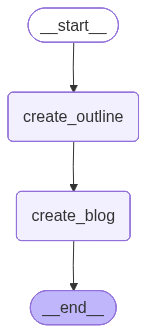

In [37]:
graph = StateGraph(BlogState)

# add nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

# add edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

# compile the graph
workflow = graph.compile()
workflow

In [38]:
initial_state = {"title": "Rise of AI in India"}
final_state = workflow.invoke(initial_state)

In [40]:
print(final_state['outline'])

Here's a detailed outline for a blog on the topic "Rise of AI in India":

**I. Introduction**

- Brief overview of Artificial Intelligence (AI)
- Importance of AI in modern times
- Thesis statement: India is witnessing a significant rise in the adoption and development of AI, which is poised to revolutionize various sectors of the economy.

**II. Current State of AI in India**

- Overview of AI initiatives in India, including:
  - AI for India initiative by the Government of India
  - National AI portal
  - AI research and development centers
- Key players in the Indian AI ecosystem, including:
  - Startups
  - Corporates
  - Research institutions

**III. AI Adoption in Various Sectors**

- **Healthcare:**
  - AI applications in medical diagnosis and treatment
  - AI-assisted telemedicine and remote health monitoring
  - Healthcare startups leveraging AI
- **Finance and Banking:**
  - AI-powered chatbots and virtual assistants
  - Predictive analytics and risk management
  - AI-driven 

In [41]:
print(final_state['content'])

**The Rise of AI in India: Revolutionizing the Economy**

Artificial Intelligence (AI) has become an integral part of modern times, transforming the way we live, work, and interact with each other. The significance of AI lies in its ability to automate tasks, improve efficiency, and make informed decisions. As the world grapples with the complexities of the fourth industrial revolution, India is witnessing a significant rise in the adoption and development of AI, which is poised to revolutionize various sectors of the economy.

**I. Introduction**

Artificial Intelligence refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. AI has numerous applications across industries, including healthcare, finance, education, and manufacturing. The importance of AI lies in its ability to improve efficiency, reduce costs, and enhance customer experience.

India is at the forefront of the